# Flight Delay Prediction

This notebook predicts whether a flight will be delayed using flight schedule data and ASOS weather data.

This version:

- Uses flight data from **2019 onward** by default.
- Defines delayed flights as **arrival delay >= 30 minutes**.
- Uses **origin weather before scheduled departure**.
- Uses **destination weather before scheduled arrival**.
- Avoids actual-time leakage.
- Trains and compares **Random Forest** and **Neural Network / MLPClassifier**.
- Uses graphs and summary tables instead of excessive printing.
- Saves the selected final model.

In [10]:
# Section 1 — Settings and imports

import gc
import joblib
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay,
)

warnings.filterwarnings("ignore")

pd.options.display.max_rows = 20
pd.options.display.max_columns = 50

# Use 2022+ by default to reduce memory.
# You can add 2019, 2020, 2021 paths here if Kaggle RAM can handle it.
FLIGHT_FILES = [
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2019.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2020.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2021.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2022.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2023.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2024.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2025.csv",
    "/kaggle/input/datasets/kamalalqedra/bts-ontime-performance-2019-present-csv/bts_ontime_2026.csv",
]

WEATHER_PATH = "/kaggle/input/datasets/sehamhakimothman/asos-weather-data-2019-2026/historical_weather_data_2019_2026.csv"

# A flight is delayed only if arrival delay is 30 minutes or more.
DELAY_THRESHOLD_MINUTES = 30

WEATHER_TOLERANCE = "3h"

# Probability threshold for turning probability into class prediction.
PREDICTION_THRESHOLD = 0.50

# Train/test split: train = before 2025, test = 2025 and later.
TEST_SPLIT_DATE = "2025-01-01"

MIN_ROUTE_COUNT = 100
RANDOM_STATE = 42

# Neural network settings
MLP_MAX_ITER = 60

FINAL_MODEL_FILE = "final_selected_delay30_origin_dest_weather.joblib"
FINAL_THRESHOLD_FILE = "final_prediction_threshold.joblib"
FINAL_DATASET_FILE = "final_modeling_dataset_delay30.parquet"

## Section 2 — Check input files

In [11]:
file_check = []

for file_path in FLIGHT_FILES:
    file_check.append({
        "file": Path(file_path).name,
        "exists": Path(file_path).exists(),
        "path": file_path
    })

file_check.append({
    "file": Path(WEATHER_PATH).name,
    "exists": Path(WEATHER_PATH).exists(),
    "path": WEATHER_PATH
})

file_check_df = pd.DataFrame(file_check)
display(file_check_df)

if not file_check_df["exists"].all():
    raise FileNotFoundError("Some input files are missing. Check the paths above.")

,file,exists,path
0,bts_ontime_2019.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
1,bts_ontime_2020.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
2,bts_ontime_2021.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
3,bts_ontime_2022.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
4,bts_ontime_2023.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
5,bts_ontime_2024.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
6,bts_ontime_2025.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
7,bts_ontime_2026.csv,True,/kaggle/input/datasets/kamalalqedra/bts-ontime...
8,historical_weather_data_2019_2026.csv,True,/kaggle/input/datasets/sehamhakimothman/asos-w...


## Section 3 — Load flight files

In [12]:
expected_flight_cols = [
    "FlightDate",
    "Reporting_Airline",
    "Origin",
    "OriginState",
    "Dest",
    "DestState",
    "CRSDepTime",
    "CRSArrTime",
    "CRSElapsedTime",
    "Distance",
    "ArrDelayMinutes",
]

flight_parts = []

for file_path in FLIGHT_FILES:
    file_path = Path(file_path)
    header = pd.read_csv(file_path, nrows=0).columns.str.strip().tolist()
    usecols = [col for col in expected_flight_cols if col in header]

    part = pd.read_csv(file_path, usecols=usecols, low_memory=False)
    part.columns = part.columns.str.strip()
    part["source_file"] = file_path.name
    flight_parts.append(part)

flights = pd.concat(flight_parts, ignore_index=True)

del flight_parts
gc.collect()

flights["FlightDate"] = pd.to_datetime(flights["FlightDate"], errors="coerce")

for col in ["Reporting_Airline", "Origin", "OriginState", "Dest", "DestState", "source_file"]:
    if col in flights.columns:
        flights[col] = flights[col].astype("string").str.strip().str.upper().astype("category")

for col in ["CRSDepTime", "CRSArrTime", "CRSElapsedTime", "Distance", "ArrDelayMinutes"]:
    if col in flights.columns:
        flights[col] = pd.to_numeric(flights[col], errors="coerce").astype("float32")

flight_summary = pd.DataFrame({
    "item": [
        "Flight files loaded",
        "Flight rows",
        "Flight columns",
        "First flight date",
        "Last flight date",
        "Memory usage MB"
    ],
    "value": [
        len(FLIGHT_FILES),
        len(flights),
        flights.shape[1],
        flights["FlightDate"].min(),
        flights["FlightDate"].max(),
        round(flights.memory_usage(deep=True).sum() / 1024**2, 2)
    ]
})

display(flight_summary)

,item,value
0,Flight files loaded,8
1,Flight rows,46307495
2,Flight columns,12
3,First flight date,2019-01-01 00:00:00
4,Last flight date,2026-01-31 00:00:00
5,Memory usage MB,1589.91


## Section 4 — Create target and scheduled local datetimes

,class,count,percentage
0,Not delayed,39602878,0.876492
1,Delayed,5580516,0.123508


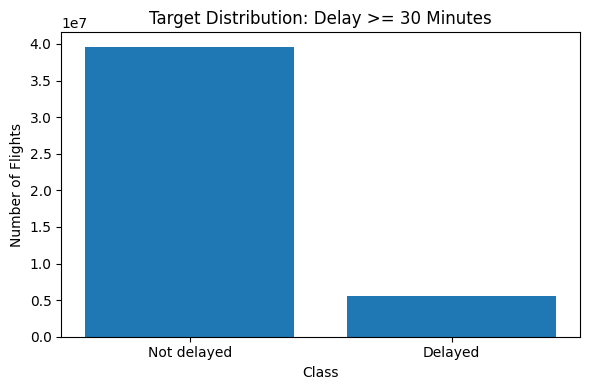

In [13]:
flights = flights.dropna(
    subset=["FlightDate", "Origin", "Dest", "CRSDepTime", "CRSArrTime", "ArrDelayMinutes"]
).copy()

flights["Delayed"] = (flights["ArrDelayMinutes"] >= DELAY_THRESHOLD_MINUTES).astype("int8")

def make_local_datetime(date_series, time_series):
    time_num = pd.to_numeric(time_series, errors="coerce")
    hours = (time_num // 100).astype("float")
    minutes = (time_num % 100).astype("float")
    hours = hours.where(hours < 24, 0)

    return (
        pd.to_datetime(date_series, errors="coerce")
        + pd.to_timedelta(hours, unit="h")
        + pd.to_timedelta(minutes, unit="m")
    )

flights["sched_dep_local"] = make_local_datetime(flights["FlightDate"], flights["CRSDepTime"])
flights["sched_arr_local"] = make_local_datetime(flights["FlightDate"], flights["CRSArrTime"])

overnight = flights["sched_arr_local"] < flights["sched_dep_local"]
flights.loc[overnight, "sched_arr_local"] = flights.loc[overnight, "sched_arr_local"] + pd.Timedelta(days=1)

target_summary = (
    flights["Delayed"]
    .value_counts()
    .rename(index={0: "Not delayed", 1: "Delayed"})
    .reset_index()
)

target_summary.columns = ["class", "count"]
target_summary["percentage"] = target_summary["count"] / target_summary["count"].sum()

display(target_summary)

plt.figure(figsize=(6, 4))
plt.bar(target_summary["class"], target_summary["count"])
plt.title("Target Distribution: Delay >= 30 Minutes")
plt.xlabel("Class")
plt.ylabel("Number of Flights")
plt.tight_layout()
plt.show()

## Section 5 — Convert scheduled departure and arrival times to UTC

In [14]:
state_to_tz = {
    "AL": "America/Chicago", "AK": "America/Anchorage", "AZ": "America/Phoenix",
    "AR": "America/Chicago", "CA": "America/Los_Angeles", "CO": "America/Denver",
    "CT": "America/New_York", "DE": "America/New_York", "FL": "America/New_York",
    "GA": "America/New_York", "HI": "Pacific/Honolulu", "IA": "America/Chicago",
    "ID": "America/Denver", "IL": "America/Chicago", "IN": "America/Indiana/Indianapolis",
    "KS": "America/Chicago", "KY": "America/New_York", "LA": "America/Chicago",
    "MA": "America/New_York", "MD": "America/New_York", "ME": "America/New_York",
    "MI": "America/New_York", "MN": "America/Chicago", "MO": "America/Chicago",
    "MS": "America/Chicago", "MT": "America/Denver", "NC": "America/New_York",
    "ND": "America/Chicago", "NE": "America/Chicago", "NH": "America/New_York",
    "NJ": "America/New_York", "NM": "America/Denver", "NV": "America/Los_Angeles",
    "NY": "America/New_York", "OH": "America/New_York", "OK": "America/Chicago",
    "OR": "America/Los_Angeles", "PA": "America/New_York", "RI": "America/New_York",
    "SC": "America/New_York", "SD": "America/Chicago", "TN": "America/Chicago",
    "TX": "America/Chicago", "UT": "America/Denver", "VA": "America/New_York",
    "VT": "America/New_York", "WA": "America/Los_Angeles", "WI": "America/Chicago",
    "WV": "America/New_York", "WY": "America/Denver",
    "PR": "America/Puerto_Rico", "VI": "America/Puerto_Rico",
    "GU": "Pacific/Guam", "TT": "America/Puerto_Rico",
}

airport_tz_overrides = {
    "EVV": "America/Chicago", "SBN": "America/Indiana/Indianapolis",
    "CVG": "America/New_York", "OWB": "America/Chicago", "PAH": "America/Chicago",
    "BNA": "America/Chicago", "MEM": "America/Chicago", "TYS": "America/New_York",
    "TRI": "America/New_York", "CHA": "America/New_York",
    "ECP": "America/Chicago", "PNS": "America/Chicago", "VPS": "America/Chicago",
    "ELP": "America/Denver",
    "BOI": "America/Denver", "PIH": "America/Denver", "TWF": "America/Denver",
    "PHX": "America/Phoenix", "TUS": "America/Phoenix", "FLG": "America/Phoenix",
    "ANC": "America/Anchorage", "FAI": "America/Anchorage", "JNU": "America/Juneau",
    "KTN": "America/Sitka", "SIT": "America/Sitka", "OME": "America/Nome",
    "HNL": "Pacific/Honolulu", "OGG": "Pacific/Honolulu", "KOA": "Pacific/Honolulu",
    "LIH": "Pacific/Honolulu",
    "SJU": "America/Puerto_Rico", "STT": "America/Puerto_Rico", "STX": "America/Puerto_Rico",
    "GUM": "Pacific/Guam", "SPN": "Pacific/Saipan", "PPG": "Pacific/Pago_Pago",
}

flights["OriginTimezone"] = flights["OriginState"].astype("string").map(state_to_tz)
flights["OriginTimezone"] = flights["Origin"].astype("string").map(airport_tz_overrides).fillna(flights["OriginTimezone"])

flights["DestTimezone"] = flights["DestState"].astype("string").map(state_to_tz)
flights["DestTimezone"] = flights["Dest"].astype("string").map(airport_tz_overrides).fillna(flights["DestTimezone"])

def add_utc_time_by_timezone(df, local_col, tz_col, out_col):
    df[out_col] = pd.NaT

    for tz, idx in df.groupby(tz_col, dropna=True).groups.items():
        local_times = pd.to_datetime(df.loc[idx, local_col], errors="coerce")
        utc_times = (
            local_times
            .dt.tz_localize(tz, ambiguous="NaT", nonexistent="shift_forward")
            .dt.tz_convert("UTC")
            .dt.tz_localize(None)
        )
        df.loc[idx, out_col] = utc_times

    return df

flights = add_utc_time_by_timezone(flights, "sched_dep_local", "OriginTimezone", "sched_dep_utc")
flights = add_utc_time_by_timezone(flights, "sched_arr_local", "DestTimezone", "sched_arr_utc")

utc_summary = pd.DataFrame({
    "item": [
        "Flights before UTC filtering",
        "Flights with scheduled departure UTC",
        "Flights with scheduled arrival UTC"
    ],
    "value": [
        len(flights),
        flights["sched_dep_utc"].notna().sum(),
        flights["sched_arr_utc"].notna().sum()
    ]
})

display(utc_summary)

flights = flights[
    flights["sched_dep_utc"].notna()
    & flights["sched_arr_utc"].notna()
].copy()

gc.collect()

,item,value
0,Flights before UTC filtering,45183394
1,Flights with scheduled departure UTC,45183349
2,Flights with scheduled arrival UTC,45183322


225

## Section 6 — Load weather in chunks with improved station mapping

In [15]:
station_special_map = {
    "PANC": "ANC", "PAFA": "FAI", "PAJN": "JNU", "PAKT": "KTN",
    "PASI": "SIT", "PAOM": "OME", "PABR": "BRW", "PABE": "BET",
    "PADQ": "ADQ", "PAHO": "HOM", "PAEN": "ENA", "PAVD": "VDZ",
    "PHNL": "HNL", "PHOG": "OGG", "PHKO": "KOA", "PHLI": "LIH",
    "PHTO": "ITO",
    "TJSJ": "SJU", "TJBQ": "BQN", "TJPS": "PSE",
    "TIST": "STT", "TISX": "STX",
    "PGUM": "GUM", "PGSN": "SPN", "NSTU": "PPG",
}

def station_to_iata(station_series):
    s = station_series.astype("string").str.strip().str.upper()
    mapped = s.map(station_special_map)
    k_rule = s.str.replace(r"^K(?=[A-Z]{3}$)", "", regex=True)
    return mapped.fillna(k_rule)

expected_weather_cols = [
    "station", "valid", "tmpf", "dwpf", "relh", "drct", "sknt", "p01i",
    "alti", "mslp", "vsby", "gust", "skyc1", "skyc2", "wxcodes", "feel",
]

weather_header = pd.read_csv(WEATHER_PATH, nrows=0).columns.str.strip().tolist()
weather_usecols = [col for col in expected_weather_cols if col in weather_header]

needed_airports = set(pd.concat([flights["Origin"].astype("string"), flights["Dest"].astype("string")]).dropna().unique())

min_weather_time = min(flights["sched_dep_utc"].min(), flights["sched_arr_utc"].min()) - pd.Timedelta(WEATHER_TOLERANCE)
max_weather_time = max(flights["sched_dep_utc"].max(), flights["sched_arr_utc"].max()) + pd.Timedelta("1d")

weather_parts = []
chunk_size = 1_000_000

for chunk in pd.read_csv(
    WEATHER_PATH, usecols=weather_usecols, chunksize=chunk_size, low_memory=False, na_values=["M", ""]
):
    chunk.columns = chunk.columns.str.strip()
    chunk["weather_iata"] = station_to_iata(chunk["station"])
    chunk = chunk[chunk["weather_iata"].isin(needed_airports)]

    if len(chunk) == 0:
        continue

    chunk["valid_utc"] = pd.to_datetime(chunk["valid"], errors="coerce", utc=True).dt.tz_localize(None)
    chunk = chunk[(chunk["valid_utc"] >= min_weather_time) & (chunk["valid_utc"] <= max_weather_time)]

    if len(chunk) == 0:
        continue

    numeric_weather_cols = ["tmpf", "dwpf", "relh", "drct", "sknt", "p01i", "alti", "mslp", "vsby", "gust", "feel"]
    for col in numeric_weather_cols:
        if col in chunk.columns:
            chunk[col] = pd.to_numeric(chunk[col], errors="coerce").astype("float32")

    if "wxcodes" in chunk.columns:
        chunk["wxcodes"] = chunk["wxcodes"].fillna("NONE").astype("string")

    for col in ["skyc1", "skyc2"]:
        if col in chunk.columns:
            chunk[col] = chunk[col].fillna("NONE").astype("string")

    weather_parts.append(chunk)

if len(weather_parts) == 0:
    raise ValueError("No weather rows matched the needed airports and time range.")

weather = pd.concat(weather_parts, ignore_index=True)

del weather_parts
gc.collect()

weather_summary = pd.DataFrame({
    "item": ["Weather rows after filtering", "Weather columns", "Matched weather airports", "First weather time", "Last weather time", "Memory usage MB"],
    "value": [
        len(weather), weather.shape[1], weather["weather_iata"].nunique(),
        weather["valid_utc"].min(), weather["valid_utc"].max(),
        round(weather.memory_usage(deep=True).sum() / 1024**2, 2)
    ]
})

display(weather_summary)

,item,value
0,Weather rows after filtering,850094
1,Weather columns,18
2,Matched weather airports,11
3,First weather time,2019-01-01 00:00:00
4,Last weather time,2026-02-03 04:54:00
5,Memory usage MB,307.01


## Section 7 — Join origin and destination scheduled weather

In [16]:
weather = weather.sort_values(["weather_iata", "valid_utc"]).reset_index(drop=True)

def merge_scheduled_weather(flights_df, weather_df, airport_col, time_col, prefix, tolerance=WEATHER_TOLERANCE):
    parts = []
    tolerance = pd.Timedelta(tolerance)
    weather_cols_to_prefix = [col for col in weather_df.columns if col not in ["station", "weather_iata", "valid", "valid_utc"]]
    flight_airports = set(flights_df[airport_col].astype("string").dropna().unique())
    weather_df = weather_df[weather_df["weather_iata"].isin(flight_airports)].copy()

    for airport, f_part in flights_df.groupby(airport_col, sort=False):
        w_part = weather_df[weather_df["weather_iata"] == str(airport)].copy()
        if len(w_part) == 0:
            continue

        merged = pd.merge_asof(
            f_part.sort_values(time_col),
            w_part.sort_values("valid_utc"),
            left_on=time_col,
            right_on="valid_utc",
            direction="backward",
            tolerance=tolerance
        )
        parts.append(merged)

    if len(parts) == 0:
        raise ValueError(f"No weather matches found for {prefix}.")

    out = pd.concat(parts, ignore_index=True)
    rename_map = {col: f"{prefix}_{col}" for col in weather_cols_to_prefix}
    rename_map.update({"valid_utc": f"{prefix}_valid_utc", "valid": f"{prefix}_valid", "station": f"{prefix}_station", "weather_iata": f"{prefix}_iata"})
    return out.rename(columns=rename_map)

model_data = merge_scheduled_weather(flights, weather, airport_col="Origin", time_col="sched_dep_utc", prefix="origin_wx")
model_data = model_data[model_data["origin_wx_valid_utc"].notna()].copy()
model_data["origin_wx_age_min"] = (model_data["sched_dep_utc"] - model_data["origin_wx_valid_utc"]).dt.total_seconds().astype("float32") / 60

model_data = merge_scheduled_weather(model_data, weather, airport_col="Dest", time_col="sched_arr_utc", prefix="dest_wx")
model_data = model_data[model_data["dest_wx_valid_utc"].notna()].copy()
model_data["dest_wx_age_min"] = (model_data["sched_arr_utc"] - model_data["dest_wx_valid_utc"]).dt.total_seconds().astype("float32") / 60

del weather
del flights
gc.collect()

join_summary = pd.DataFrame({
    "item": ["Rows after origin + destination weather join", "Origin airports matched", "Destination airports matched", "Delayed rate", "Memory usage MB"],
    "value": [
        len(model_data), model_data["Origin"].nunique(), model_data["Dest"].nunique(),
        round(model_data["Delayed"].mean(), 4), round(model_data.memory_usage(deep=True).sum() / 1024**2, 2)
    ]
})

display(join_summary)

,item,value
0,Rows after origin + destination weather join,63327.0000
1,Origin airports matched,8.0000
2,Destination airports matched,8.0000
3,Delayed rate,0.1355
4,Memory usage MB,58.6600


## Section 8 — Feature engineering

In [17]:
model_data["dep_hour"] = model_data["sched_dep_local"].dt.hour.astype("float32")
model_data["arr_hour"] = model_data["sched_arr_local"].dt.hour.astype("float32")
model_data["dep_month"] = model_data["sched_dep_local"].dt.month.astype("float32")
model_data["dep_dayofweek"] = model_data["sched_dep_local"].dt.dayofweek.astype("float32")
model_data["is_weekend"] = model_data["dep_dayofweek"].isin([5, 6]).astype("int8")

model_data["route"] = model_data["Origin"].astype("string") + "_" + model_data["Dest"].astype("string")
route_counts = model_data["route"].value_counts()
common_routes = route_counts[route_counts >= MIN_ROUTE_COUNT].index
model_data["route_clean"] = model_data["route"].where(model_data["route"].isin(common_routes), "OTHER")

origin_wx_codes = model_data["origin_wx_wxcodes"].fillna("NONE").astype("string")
dest_wx_codes = model_data["dest_wx_wxcodes"].fillna("NONE").astype("string")

model_data["origin_wx_rain"] = origin_wx_codes.str.contains("RA", regex=False).astype("int8")
model_data["origin_wx_snow"] = origin_wx_codes.str.contains("SN", regex=False).astype("int8")
model_data["origin_wx_fog"] = origin_wx_codes.str.contains("FG|BR", regex=True).astype("int8")
model_data["origin_wx_thunder"] = origin_wx_codes.str.contains("TS", regex=False).astype("int8")

model_data["dest_wx_rain"] = dest_wx_codes.str.contains("RA", regex=False).astype("int8")
model_data["dest_wx_snow"] = dest_wx_codes.str.contains("SN", regex=False).astype("int8")
model_data["dest_wx_fog"] = dest_wx_codes.str.contains("FG|BR", regex=True).astype("int8")
model_data["dest_wx_thunder"] = dest_wx_codes.str.contains("TS", regex=False).astype("int8")

numeric_features = [
    "dep_hour", "arr_hour", "dep_month", "dep_dayofweek", "is_weekend", "CRSElapsedTime", "Distance",
    "origin_wx_tmpf", "origin_wx_dwpf", "origin_wx_relh", "origin_wx_drct", "origin_wx_sknt", "origin_wx_p01i",
    "origin_wx_alti", "origin_wx_mslp", "origin_wx_vsby", "origin_wx_gust", "origin_wx_feel", "origin_wx_age_min",
    "origin_wx_rain", "origin_wx_snow", "origin_wx_fog", "origin_wx_thunder",
    "dest_wx_tmpf", "dest_wx_dwpf", "dest_wx_relh", "dest_wx_drct", "dest_wx_sknt", "dest_wx_p01i",
    "dest_wx_alti", "dest_wx_mslp", "dest_wx_vsby", "dest_wx_gust", "dest_wx_feel", "dest_wx_age_min",
    "dest_wx_rain", "dest_wx_snow", "dest_wx_fog", "dest_wx_thunder",
]
numeric_features = [col for col in numeric_features if col in model_data.columns]

categorical_features = ["Reporting_Airline", "Origin", "Dest", "origin_wx_skyc1", "origin_wx_skyc2", "dest_wx_skyc1", "dest_wx_skyc2"]
categorical_features = [col for col in categorical_features if col in model_data.columns]

feature_summary = pd.DataFrame({
    "feature_type": ["numeric", "categorical", "total"],
    "count": [len(numeric_features), len(categorical_features), len(numeric_features) + len(categorical_features)]
})

display(feature_summary)

,feature_type,count
0,numeric,39
1,categorical,7
2,total,46


## Section 9 — Route delay-rate analysis

,total_flights,delay_rate
route,,
ORD_UIN,585,0.215385
ORD_SPI,2011,0.172054
UIN_ORD,583,0.159520
ORD_PIA,7784,0.148895
PIA_ORD,7791,0.143627
ORD_CMI,6082,0.140743
ORD_MLI,8394,0.139862
MLI_ORD,8391,0.135264
SPI_ORD,2063,0.135240


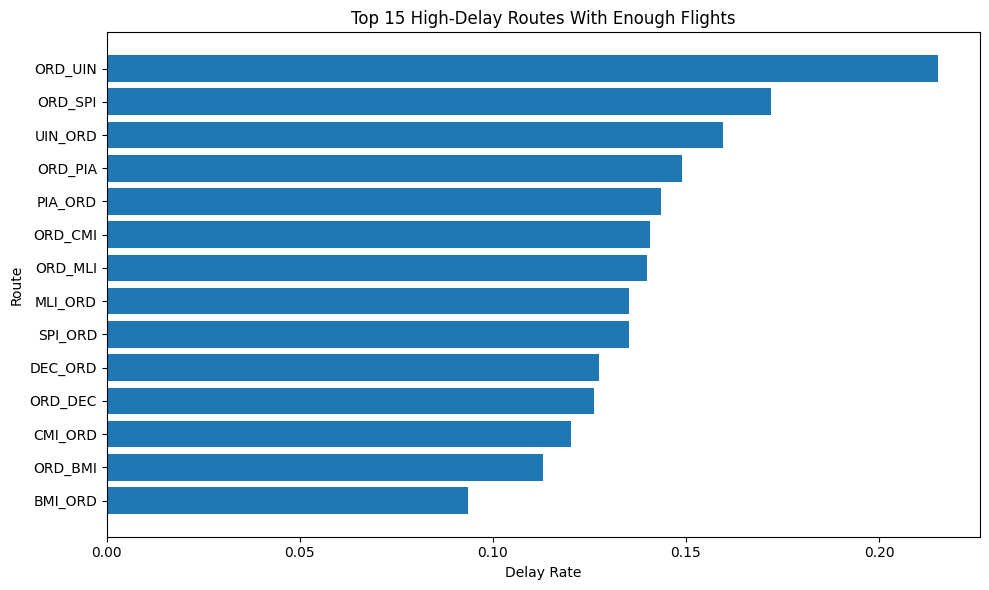

In [18]:
route_summary = (
    model_data.groupby("route")
    .agg(total_flights=("Delayed", "size"), delay_rate=("Delayed", "mean"))
    .query("total_flights >= @MIN_ROUTE_COUNT")
    .sort_values("delay_rate", ascending=False)
)

top_routes = route_summary.head(15).sort_values("delay_rate")
display(route_summary.head(10))

plt.figure(figsize=(10, 6))
plt.barh(top_routes.index, top_routes["delay_rate"])
plt.xlabel("Delay Rate")
plt.ylabel("Route")
plt.title("Top 15 High-Delay Routes With Enough Flights")
plt.tight_layout()
plt.show()

## Section 10 — Train/test split

In [19]:
split_date = pd.Timestamp(TEST_SPLIT_DATE)
train_df = model_data[model_data["FlightDate"] < split_date].copy()
test_df = model_data[model_data["FlightDate"] >= split_date].copy()

if len(train_df) == 0 or len(test_df) == 0:
    train_df, test_df = train_test_split(model_data, test_size=0.2, random_state=RANDOM_STATE, stratify=model_data["Delayed"])

X_train = train_df[numeric_features + categorical_features]
y_train = train_df["Delayed"].astype("int8")
X_test = test_df[numeric_features + categorical_features]
y_test = test_df["Delayed"].astype("int8")

split_summary = pd.DataFrame({"dataset": ["train", "test"], "rows": [len(train_df), len(test_df)], "delayed_rate": [y_train.mean(), y_test.mean()]})
display(split_summary)

,dataset,rows,delayed_rate
0,train,49209,0.120913
1,test,14118,0.186287


## Section 11 — Preprocessing pipelines

In [20]:
rf_preprocess = ColumnTransformer(
    transformers=[
        ("num", SimpleImputer(strategy="median"), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", dtype=np.float32))
        ]), categorical_features),
    ],
    sparse_threshold=1.0
)

nn_preprocess = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler(with_mean=False))
        ]), numeric_features),
        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", dtype=np.float32))
        ]), categorical_features),
    ],
    sparse_threshold=1.0
)

## Section 12 — Train Random Forest

In [21]:
random_forest_model = Pipeline(steps=[
    ("preprocess", rf_preprocess),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=10,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

random_forest_model.fit(X_train, y_train)
rf_proba = random_forest_model.predict_proba(X_test)[:, 1]
rf_pred = (rf_proba >= PREDICTION_THRESHOLD).astype(int)

rf_metrics = pd.DataFrame([{
    "model": "Random Forest",
    "delay_definition_minutes": DELAY_THRESHOLD_MINUTES,
    "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, rf_pred),
    "precision_delayed": precision_score(y_test, rf_pred, zero_division=0),
    "recall_delayed": recall_score(y_test, rf_pred, zero_division=0),
    "f1_delayed": f1_score(y_test, rf_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, rf_proba),
    "average_precision": average_precision_score(y_test, rf_proba),
}])

display(rf_metrics)

,model,delay_definition_minutes,prediction_threshold,accuracy,precision_delayed,recall_delayed,f1_delayed,roc_auc,average_precision
0,Random Forest,30,0.5,0.816475,0.513131,0.289734,0.370352,0.728335,0.434235


## Section 13 — Train Neural Network

In [22]:
neural_network_model = Pipeline(steps=[
    ("preprocess", nn_preprocess),
    ("model", MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation="relu",
        solver="adam",
        alpha=0.0005,
        batch_size=512,
        learning_rate_init=0.001,
        max_iter=MLP_MAX_ITER,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=8,
        random_state=RANDOM_STATE,
        verbose=False
    ))
])

neural_network_model.fit(X_train, y_train)
nn_proba = neural_network_model.predict_proba(X_test)[:, 1]
nn_pred = (nn_proba >= PREDICTION_THRESHOLD).astype(int)

nn_metrics = pd.DataFrame([{
    "model": "Neural Network",
    "delay_definition_minutes": DELAY_THRESHOLD_MINUTES,
    "prediction_threshold": PREDICTION_THRESHOLD,
    "accuracy": accuracy_score(y_test, nn_pred),
    "precision_delayed": precision_score(y_test, nn_pred, zero_division=0),
    "recall_delayed": recall_score(y_test, nn_pred, zero_division=0),
    "f1_delayed": f1_score(y_test, nn_pred, zero_division=0),
    "roc_auc": roc_auc_score(y_test, nn_proba),
    "average_precision": average_precision_score(y_test, nn_proba),
}])

display(nn_metrics)

,model,delay_definition_minutes,prediction_threshold,accuracy,precision_delayed,recall_delayed,f1_delayed,roc_auc,average_precision
0,Neural Network,30,0.5,0.820654,0.699187,0.065399,0.119611,0.671874,0.373601


## Section 14 — Compare Random Forest and Neural Network

,model,delay_definition_minutes,prediction_threshold,accuracy,precision_delayed,recall_delayed,f1_delayed,roc_auc,average_precision
0,Random Forest,30,0.5,0.816475,0.513131,0.289734,0.370352,0.728335,0.434235
1,Neural Network,30,0.5,0.820654,0.699187,0.065399,0.119611,0.671874,0.373601


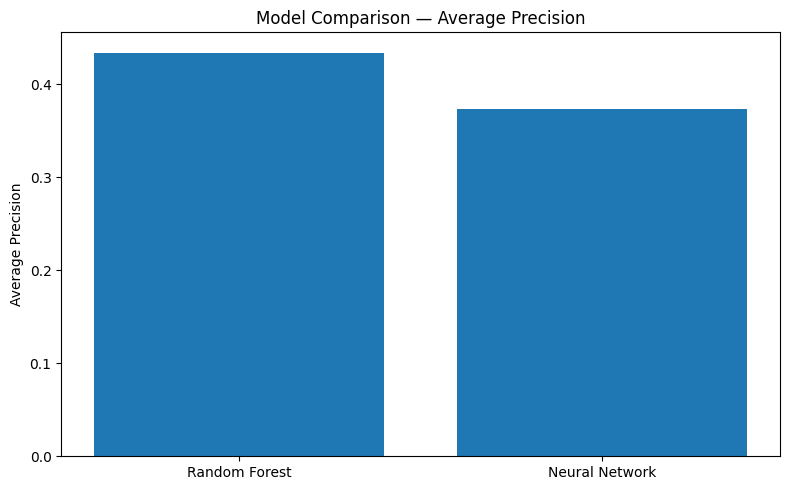

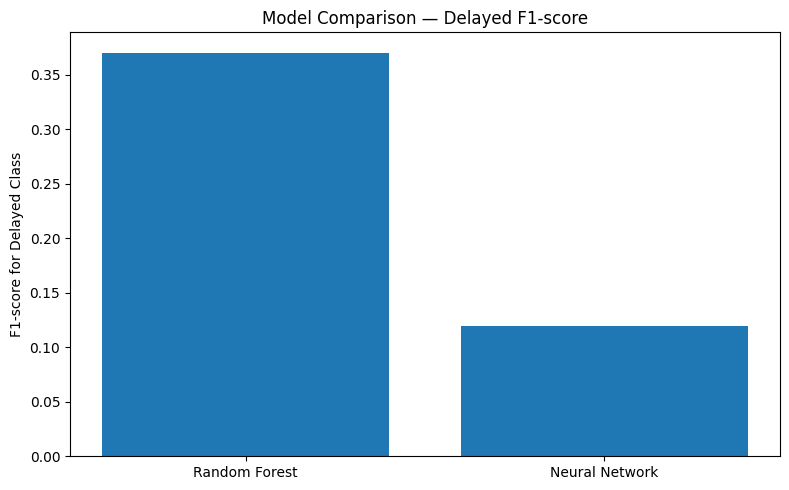

In [23]:
model_comparison = pd.concat([rf_metrics, nn_metrics], ignore_index=True)
display(model_comparison.sort_values(["average_precision", "roc_auc"], ascending=False).reset_index(drop=True))

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["model"], model_comparison["average_precision"])
plt.title("Model Comparison — Average Precision")
plt.ylabel("Average Precision")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
plt.bar(model_comparison["model"], model_comparison["f1_delayed"])
plt.title("Model Comparison — Delayed F1-score")
plt.ylabel("F1-score for Delayed Class")
plt.tight_layout()
plt.show()

## Section 15 — Confusion matrix graphs

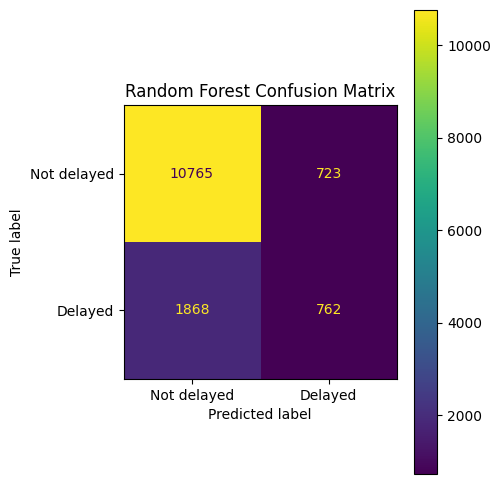

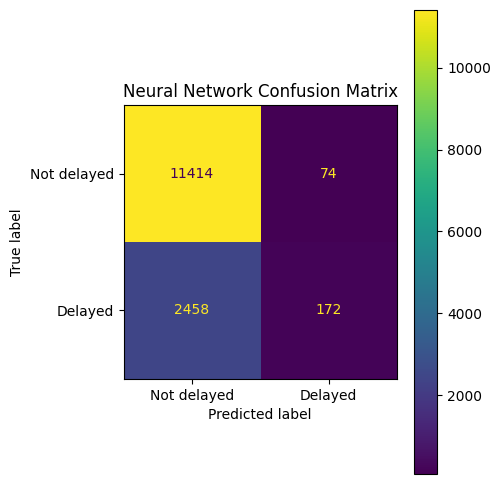

In [24]:
fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_pred, display_labels=["Not delayed", "Delayed"], ax=ax, values_format="d")
ax.set_title("Random Forest Confusion Matrix")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, nn_pred, display_labels=["Not delayed", "Delayed"], ax=ax, values_format="d")
ax.set_title("Neural Network Confusion Matrix")
plt.tight_layout()
plt.show()

## Section 16 — ROC curves

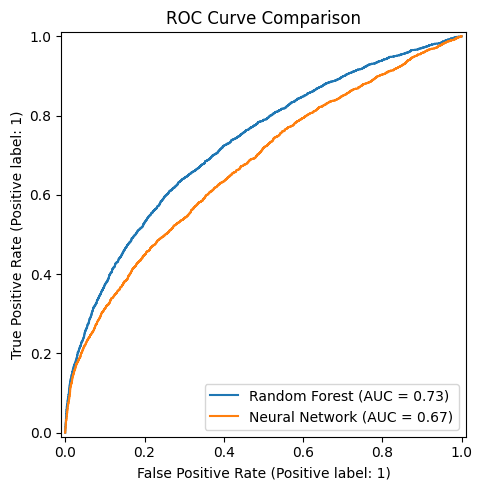

In [25]:
fig, ax = plt.subplots(figsize=(7, 5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
RocCurveDisplay.from_predictions(y_test, nn_proba, name="Neural Network", ax=ax)
ax.set_title("ROC Curve Comparison")
plt.tight_layout()
plt.show()

## Section 17 — Precision-recall curves

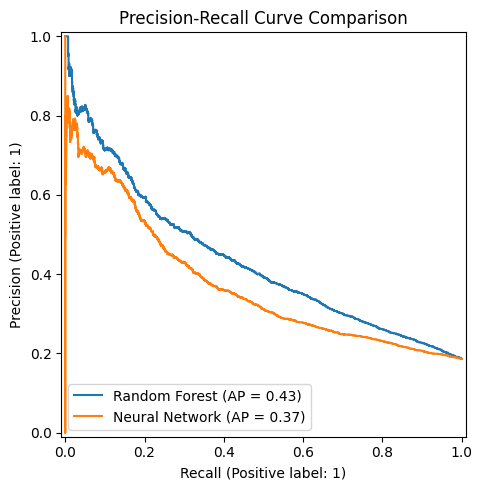

In [26]:
fig, ax = plt.subplots(figsize=(7, 5))
PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name="Random Forest", ax=ax)
PrecisionRecallDisplay.from_predictions(y_test, nn_proba, name="Neural Network", ax=ax)
ax.set_title("Precision-Recall Curve Comparison")
plt.tight_layout()
plt.show()

## Section 18 — Threshold comparison for both models

,model,threshold,accuracy,precision_delayed,recall_delayed,f1_delayed
0,Random Forest,0.20,0.354016,0.215051,0.931179,0.349408
1,Random Forest,0.25,0.488525,0.245932,0.844867,0.380969
2,Random Forest,0.30,0.616376,0.289641,0.729278,0.414613
3,Random Forest,0.35,0.708386,0.342512,0.614829,0.439940
4,Random Forest,0.40,0.766114,0.397248,0.493916,0.440339
...,...,...,...,...,...,...
21,Neural Network,0.60,0.817325,0.700787,0.033840,0.064563
22,Neural Network,0.65,0.817113,0.766667,0.026236,0.050735
23,Neural Network,0.70,0.815555,0.740741,0.015209,0.029806
24,Neural Network,0.75,0.815130,0.794118,0.010266,0.020270


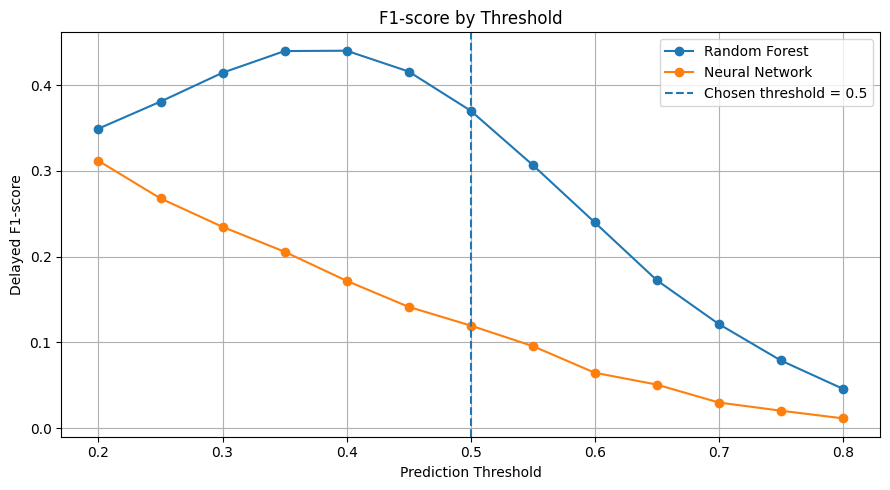

In [27]:
threshold_values = np.arange(0.20, 0.81, 0.05)
threshold_rows = []

for model_name, proba in [("Random Forest", rf_proba), ("Neural Network", nn_proba)]:
    for threshold in threshold_values:
        pred_t = (proba >= threshold).astype(int)
        threshold_rows.append({
            "model": model_name,
            "threshold": round(float(threshold), 2),
            "accuracy": accuracy_score(y_test, pred_t),
            "precision_delayed": precision_score(y_test, pred_t, zero_division=0),
            "recall_delayed": recall_score(y_test, pred_t, zero_division=0),
            "f1_delayed": f1_score(y_test, pred_t, zero_division=0),
        })

threshold_df = pd.DataFrame(threshold_rows)
display(threshold_df)

plt.figure(figsize=(9, 5))
for model_name in threshold_df["model"].unique():
    part = threshold_df[threshold_df["model"] == model_name]
    plt.plot(part["threshold"], part["f1_delayed"], marker="o", label=model_name)

plt.axvline(PREDICTION_THRESHOLD, linestyle="--", label=f"Chosen threshold = {PREDICTION_THRESHOLD}")
plt.xlabel("Prediction Threshold")
plt.ylabel("Delayed F1-score")
plt.title("F1-score by Threshold")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Section 19 — Choose final model

In [28]:
best_model_name = model_comparison.sort_values(["average_precision", "roc_auc"], ascending=False).iloc[0]["model"]

if best_model_name == "Random Forest":
    selected_model = random_forest_model
else:
    selected_model = neural_network_model

selected_summary = pd.DataFrame({
    "item": ["Selected final model", "Selection rule", "Prediction threshold"],
    "value": [best_model_name, "Highest average precision, then ROC AUC", PREDICTION_THRESHOLD]
})

display(selected_summary)

,item,value
0,Selected final model,Random Forest
1,Selection rule,"Highest average precision, then ROC AUC"
2,Prediction threshold,0.5


## Section 20 — Train final selected model on all prepared data

In [29]:
final_X = model_data[numeric_features + categorical_features]
final_y = model_data["Delayed"].astype("int8")

if best_model_name == "Random Forest":
    final_model = Pipeline(steps=[
        ("preprocess", rf_preprocess),
        ("model", RandomForestClassifier(
            n_estimators=200,
            max_depth=20,
            min_samples_leaf=10,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        ))
    ])
else:
    final_model = Pipeline(steps=[
        ("preprocess", nn_preprocess),
        ("model", MLPClassifier(
            hidden_layer_sizes=(64, 32),
            activation="relu",
            solver="adam",
            alpha=0.0005,
            batch_size=512,
            learning_rate_init=0.001,
            max_iter=MLP_MAX_ITER,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=8,
            random_state=RANDOM_STATE,
            verbose=False
        ))
    ])

final_model.fit(final_X, final_y)

final_training_summary = pd.DataFrame({
    "item": ["Final model", "Rows used for final training", "Delay definition", "Features used", "Prediction threshold"],
    "value": [best_model_name, len(final_X), f"ArrDelayMinutes >= {DELAY_THRESHOLD_MINUTES}", len(numeric_features) + len(categorical_features), PREDICTION_THRESHOLD]
})

display(final_training_summary)

,item,value
0,Final model,Random Forest
1,Rows used for final training,63327
2,Delay definition,ArrDelayMinutes >= 30
3,Features used,46
4,Prediction threshold,0.5


## Section 21 — Final model sanity check

,sample_rows,accuracy,precision_delayed,recall_delayed,f1_delayed
0,63327,0.923461,0.685077,0.805245,0.740316


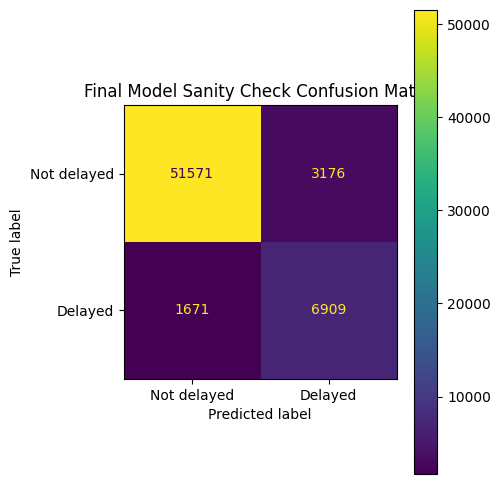

21967

In [30]:
if len(final_X) > 200_000:
    sanity_sample, _ = train_test_split(model_data, train_size=200_000, random_state=RANDOM_STATE, stratify=model_data["Delayed"])
else:
    sanity_sample = model_data.copy()

X_sanity = sanity_sample[numeric_features + categorical_features]
y_sanity = sanity_sample["Delayed"].astype("int8")

sanity_proba = final_model.predict_proba(X_sanity)[:, 1]
sanity_pred = (sanity_proba >= PREDICTION_THRESHOLD).astype(int)

sanity_metrics = pd.DataFrame([{
    "sample_rows": len(sanity_sample),
    "accuracy": accuracy_score(y_sanity, sanity_pred),
    "precision_delayed": precision_score(y_sanity, sanity_pred, zero_division=0),
    "recall_delayed": recall_score(y_sanity, sanity_pred, zero_division=0),
    "f1_delayed": f1_score(y_sanity, sanity_pred, zero_division=0)
}])

display(sanity_metrics)

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_sanity, sanity_pred, display_labels=["Not delayed", "Delayed"], ax=ax, values_format="d")
ax.set_title("Final Model Sanity Check Confusion Matrix")
plt.tight_layout()
plt.show()

del sanity_sample, X_sanity, y_sanity, sanity_proba, sanity_pred
gc.collect()

## Section 22 — Save final model, threshold, and dataset

In [31]:
joblib.dump(final_model, FINAL_MODEL_FILE)
joblib.dump(PREDICTION_THRESHOLD, FINAL_THRESHOLD_FILE)

save_cols = numeric_features + categorical_features + [
    "Delayed", "FlightDate", "sched_dep_local", "sched_arr_local", "sched_dep_utc", "sched_arr_utc", "Origin", "Dest", "Reporting_Airline", "route",
]
save_cols = list(dict.fromkeys([col for col in save_cols if col in model_data.columns]))
model_data[save_cols].to_parquet(FINAL_DATASET_FILE, index=False)

saved_files = pd.DataFrame({
    "file": [FINAL_MODEL_FILE, FINAL_THRESHOLD_FILE, FINAL_DATASET_FILE],
    "exists": [Path(FINAL_MODEL_FILE).exists(), Path(FINAL_THRESHOLD_FILE).exists(), Path(FINAL_DATASET_FILE).exists()],
    "size_MB": [
        round(Path(FINAL_MODEL_FILE).stat().st_size / 1024**2, 2) if Path(FINAL_MODEL_FILE).exists() else None,
        round(Path(FINAL_THRESHOLD_FILE).stat().st_size / 1024**2, 2) if Path(FINAL_THRESHOLD_FILE).exists() else None,
        round(Path(FINAL_DATASET_FILE).stat().st_size / 1024**2, 2) if Path(FINAL_DATASET_FILE).exists() else None,
    ]
})

display(saved_files)

,file,exists,size_MB
0,final_selected_delay30_origin_dest_weather.joblib,True,61.44
1,final_prediction_threshold.joblib,True,0.00
2,final_modeling_dataset_delay30.parquet,True,3.90


## Section 23 — Test loading the saved model

In [32]:
loaded_model = joblib.load(FINAL_MODEL_FILE)
loaded_threshold = joblib.load(FINAL_THRESHOLD_FILE)

sample_rows = final_X.head(10).copy()
sample_proba = loaded_model.predict_proba(sample_rows)[:, 1]
sample_pred = (sample_proba >= loaded_threshold).astype(int)

sample_output = sample_rows.copy()
sample_output["delay_probability"] = sample_proba
sample_output["predicted_delayed"] = sample_pred

display(sample_output)

,dep_hour,arr_hour,dep_month,dep_dayofweek,is_weekend,CRSElapsedTime,Distance,origin_wx_tmpf,origin_wx_dwpf,origin_wx_relh,origin_wx_drct,origin_wx_sknt,origin_wx_p01i,origin_wx_alti,origin_wx_mslp,origin_wx_vsby,origin_wx_gust,origin_wx_feel,origin_wx_age_min,origin_wx_rain,origin_wx_snow,origin_wx_fog,origin_wx_thunder,dest_wx_tmpf,dest_wx_dwpf,dest_wx_relh,dest_wx_drct,dest_wx_sknt,dest_wx_p01i,dest_wx_alti,dest_wx_mslp,dest_wx_vsby,dest_wx_gust,dest_wx_feel,dest_wx_age_min,dest_wx_rain,dest_wx_snow,dest_wx_fog,dest_wx_thunder,Reporting_Airline,Origin,Dest,origin_wx_skyc1,origin_wx_skyc2,dest_wx_skyc1,dest_wx_skyc2,delay_probability,predicted_delayed
0,7.0,9.0,1.0,1.0,0,70.0,174.0,28.9,24.1,82.000000,20.0,10.0,NaN,30.240000,1024.900024,10.0,NaN,19.080000,4.0,0,0,0,0,34.0,32.0,92.290001,330.0,6.0,0.0,30.299999,1026.400024,5.00,NaN,27.940001,13.0,0,0,1,0,OO,ORD,SPI,OVC,NONE,OVC,NONE,0.546686,1
1,17.0,18.0,1.0,1.0,0,64.0,174.0,26.1,21.9,83.889999,340.0,5.0,0.0,30.299999,1027.099976,10.0,NaN,19.389999,34.0,0,0,0,0,32.0,30.9,95.650002,310.0,5.0,0.0,30.340000,NaN,2.50,NaN,26.400000,8.0,0,0,1,0,OO,ORD,SPI,OVC,NONE,OVC,NONE,0.528256,1
2,21.0,22.0,1.0,1.0,0,64.0,174.0,26.1,23.0,87.870003,350.0,4.0,0.0,30.299999,NaN,10.0,NaN,20.530001,8.0,0,0,0,0,30.0,30.0,100.000000,310.0,6.0,0.0,30.320000,1027.300049,0.75,NaN,23.120001,32.0,0,0,1,0,OO,ORD,SPI,OVC,NONE,OVC,NONE,0.691748,1
3,7.0,9.0,1.0,2.0,0,70.0,174.0,28.9,27.0,92.489998,200.0,4.0,NaN,30.180000,1022.900024,5.0,NaN,23.799999,4.0,0,0,1,0,30.0,26.1,85.209999,200.0,6.0,0.0,30.240000,NaN,9.00,NaN,23.120001,13.0,0,0,0,0,OO,ORD,SPI,OVC,NONE,OVC,NONE,0.400231,0
4,17.0,18.0,1.0,2.0,0,64.0,174.0,28.9,21.9,74.760002,230.0,13.0,0.0,29.980000,1015.900024,10.0,19.0,17.600000,34.0,0,0,0,0,28.9,23.0,78.300003,260.0,13.0,0.0,30.120001,1020.599976,10.00,NaN,17.600000,37.0,0,0,0,0,OO,ORD,SPI,BKN,OVC,OVC,NONE,0.524513,1
5,21.0,22.0,1.0,2.0,0,64.0,174.0,28.0,19.9,71.250000,260.0,9.0,0.0,30.040001,1018.200012,10.0,NaN,18.540001,29.0,0,0,0,0,28.0,24.1,85.080002,260.0,8.0,0.0,30.120001,1020.599976,10.00,NaN,19.190001,32.0,0,0,0,0,OO,ORD,SPI,FEW,OVC,CLR,NONE,0.590850,1
6,7.0,9.0,1.0,3.0,0,70.0,174.0,24.1,21.9,91.169998,220.0,7.0,0.0,30.040001,1018.000000,9.0,NaN,15.150000,4.0,0,0,0,0,28.0,24.1,85.080002,200.0,7.0,0.0,30.139999,1021.299988,10.00,NaN,19.900000,13.0,0,0,0,0,OO,ORD,SPI,CLR,NONE,CLR,NONE,0.277516,0
7,17.0,18.0,1.0,3.0,0,64.0,174.0,37.0,28.9,72.239998,210.0,10.0,0.0,29.920000,1014.099976,10.0,NaN,29.240000,34.0,0,0,0,0,34.0,28.0,78.430000,190.0,5.0,0.0,30.030001,1017.599976,10.00,NaN,28.770000,37.0,0,0,0,0,OO,ORD,SPI,FEW,NONE,CLR,NONE,0.234011,0
8,21.0,22.0,1.0,3.0,0,64.0,174.0,35.0,28.9,77.879997,210.0,11.0,0.0,29.920000,1013.700012,10.0,NaN,26.379999,29.0,0,0,0,0,30.0,27.0,88.440002,170.0,4.0,0.0,30.000000,1016.299988,10.00,NaN,25.080000,32.0,0,0,0,0,OO,ORD,SPI,CLR,NONE,CLR,NONE,0.205125,0
9,7.0,9.0,1.0,4.0,0,70.0,174.0,32.0,27.0,81.550003,230.0,8.0,0.0,29.820000,1010.400024,10.0,NaN,24.110001,4.0,0,0,0,0,28.9,28.0,96.379997,150.0,4.0,0.0,29.850000,1011.599976,5.00,NaN,23.799999,13.0,0,0,1,0,OO,ORD,SPI,FEW,NONE,CLR,NONE,0.350789,0


## Section 24 — Final project conclusion

In [33]:
final_conclusion = (
    "This notebook predicts whether a flight will be delayed by 30 minutes or more. "
    "It joins flight data with origin weather before scheduled departure and destination weather before scheduled arrival. "
    "Actual departure time, actual arrival time, and actual delay-causing columns are not used as model inputs, which avoids data leakage. "
    "Random Forest and Neural Network models are trained and compared using accuracy, precision, recall, F1-score, ROC AUC, average precision, "
    "confusion matrices, ROC curves, and precision-recall curves. "
    "The final model is selected based on average precision and ROC AUC, then retrained on all prepared data and saved."
)

print(final_conclusion)

This notebook predicts whether a flight will be delayed by 30 minutes or more. It joins flight data with origin weather before scheduled departure and destination weather before scheduled arrival. Actual departure time, actual arrival time, and actual delay-causing columns are not used as model inputs, which avoids data leakage. Random Forest and Neural Network models are trained and compared using accuracy, precision, recall, F1-score, ROC AUC, average precision, confusion matrices, ROC curves, and precision-recall curves. The final model is selected based on average precision and ROC AUC, then retrained on all prepared data and saved.
